# Langara VR ECE App — Research Queries

**Research Focus:** How does the VR app support ECE student learning?

**Connection:** Trino → MongoDB (`mongo_prod` catalog, `langara-dev-client` schema)

**SSH tunnel required:**
```bash
ssh -L 8080:localhost:8080 <user>@20.151.177.201
```

**Tables:**
- `levelflows` — one row per student session (includes `scene[]` JSON array + `conversations[]` nested inside)
- `users` — student/instructor accounts
- `levels` — level definitions
- `trainingmodels` — NLP model accuracy records

---

## Sections
1. [Setup](#1-setup)
2. [Existing Dashboard Queries (Charts 01–18)](#2-existing-dashboard-queries)
3. [New Research Queries](#3-new-research-queries)

## 1. Setup

In [11]:
# pip install trino pandas matplotlib seaborn
import trino
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid')

TRINO_HOST = 'localhost'   # SSH tunnel: ssh -L 8080:localhost:8080 <user>@20.151.177.201
TRINO_PORT = 8080
TRINO_USER = 'admin'
CATALOG    = 'mongo_prod'
SCHEMA     = 'langara-dev-client'

conn = trino.dbapi.connect(
    host=TRINO_HOST,
    port=TRINO_PORT,
    user=TRINO_USER,
    catalog=CATALOG,
    schema=SCHEMA,
)

def query(sql):
    """Run a Trino SQL query and return a pandas DataFrame."""
    cur = conn.cursor()
    cur.execute(sql)
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description]
    return pd.DataFrame(rows, columns=cols)

print('Connected to Trino.')

Connected to Trino.


## 2. Existing Dashboard Queries

These are the queries from the Langara Superset Dashboard Guide v5.

### CHART-01 — Level Completion Funnel
**Q:** How many students complete each level vs. how many attempted it?

In [12]:
df_01 = query("""
SELECT
    lf.levelname                                                   AS level_name,
    COUNT(DISTINCT lf.userid)                                      AS students_attempted,
    SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)       AS students_completed,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(DISTINCT lf.userid), 0), 1
    ), 0)                                                          AS completion_rate_pct
FROM levelflows lf
GROUP BY lf.levelname
ORDER BY MIN(lf."create")
""")

df_01

,level_name,students_attempted,students_completed,completion_rate_pct
0,Demo Train,14,32,228.600000000000000
1,Demo Snack,15,74,493.300000000000000
2,Demo Birthday,14,20,142.900000000000000
3,Snack Table 3 fake,8,0,0E-15


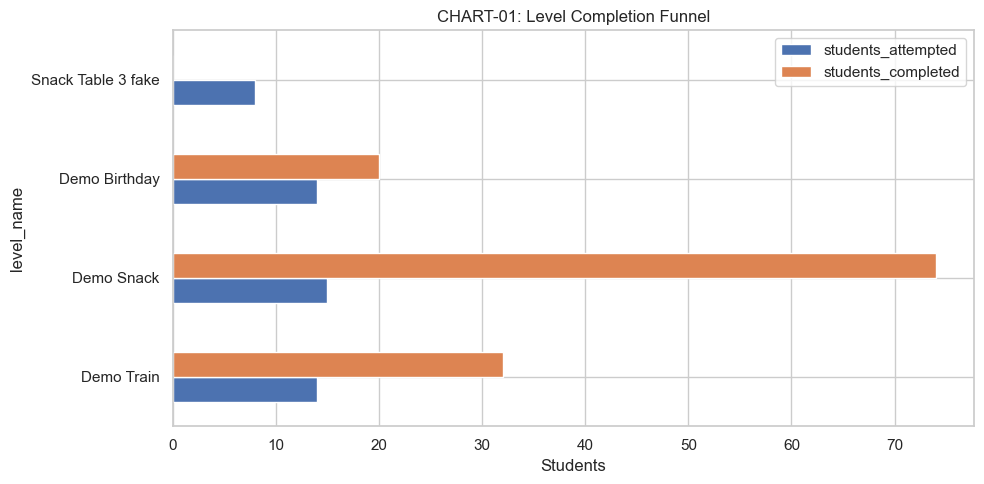

In [13]:
ax = df_01.set_index('level_name')[['students_attempted','students_completed']].plot(
    kind='barh', figsize=(10, 5), title='CHART-01: Level Completion Funnel'
)
ax.set_xlabel('Students')
plt.tight_layout()
plt.show()

### CHART-02 — Scene-by-Scene Drop-Off
**Q:** Which scene numbers have the highest failure rate across all levels?

In [14]:
df_02 = query("""
SELECT
    CAST(json_extract_scalar(scene_obj, '$.sceneNo') AS BIGINT)    AS scene_no,
    lf.levelname                                                   AS level_name,
    COUNT(*)                                                       AS total_attempts,
    SUM(CASE WHEN json_extract_scalar(scene_obj, '$.sceneComplete') = 'true' THEN 1 ELSE 0 END) AS scenes_completed,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN json_extract_scalar(scene_obj, '$.sceneComplete') = 'true' THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS scene_completion_pct
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
GROUP BY json_extract_scalar(scene_obj, '$.sceneNo'), lf.levelname
ORDER BY lf.levelname, scene_no
""")

df_02

,scene_no,level_name,total_attempts,scenes_completed,scene_completion_pct
0,1,Demo Birthday,112,112,100.000000000000000
1,2,Demo Birthday,78,59,75.600000000000000
2,3,Demo Birthday,48,41,85.400000000000000
3,4,Demo Birthday,38,37,97.400000000000000
4,5,Demo Birthday,35,27,77.100000000000000
5,6,Demo Birthday,27,27,100.000000000000000
6,7,Demo Birthday,27,25,92.600000000000000
7,8,Demo Birthday,25,25,100.000000000000000
8,9,Demo Birthday,24,23,95.800000000000000
9,10,Demo Birthday,27,27,100.000000000000000


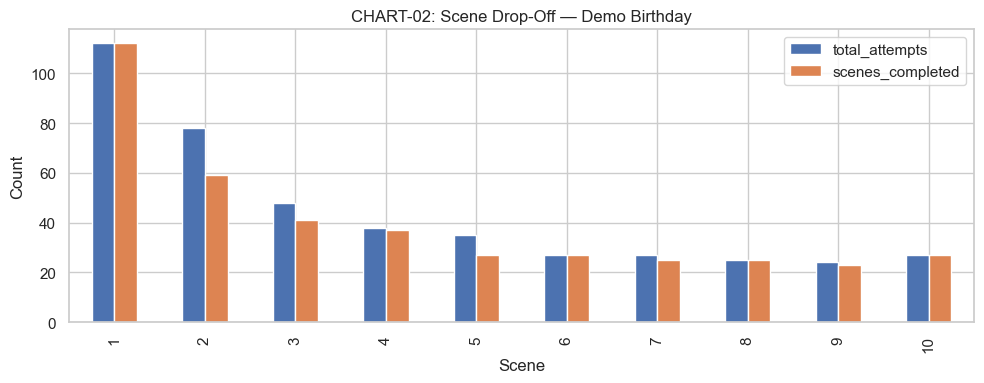

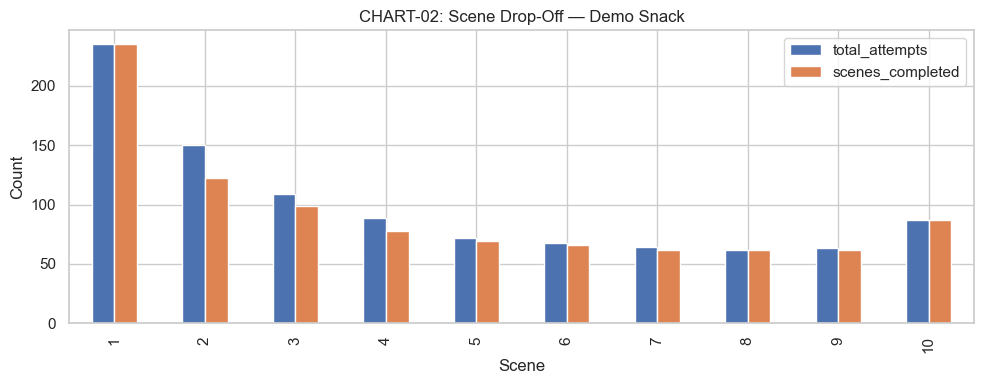

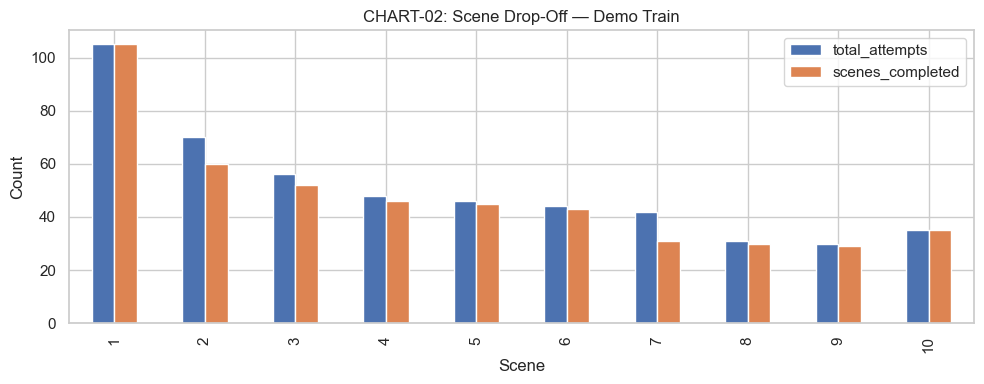

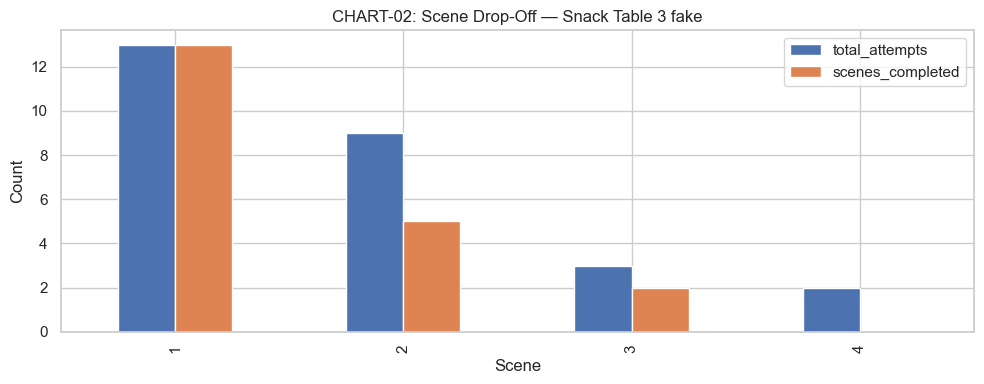

In [15]:
for level, grp in df_02.groupby('level_name'):
    fig, ax = plt.subplots(figsize=(10, 4))
    grp.set_index('scene_no')[['total_attempts','scenes_completed']].plot(
        kind='bar', ax=ax, title=f'CHART-02: Scene Drop-Off — {level}'
    )
    ax.set_xlabel('Scene')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

### CHART-03 — Attempts Before Completion (Box Plot)
**Q:** How many tries does it take the average student to complete a level?

In [16]:
df_03 = query("""
SELECT
    lf.userid                                                      AS user_id,
    lf.levelname                                                   AS level_name,
    COUNT(*)                                                       AS attempt_count,
    MAX(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)       AS eventually_completed
FROM levelflows lf
GROUP BY lf.userid, lf.levelname
ORDER BY attempt_count DESC
""")

df_03

,user_id,level_name,attempt_count,eventually_completed
0,ZcIFLWv+f61kKsW1,Demo Snack,109,1
1,Z/tj3mwE0UzuKdyl,Demo Snack,63,1
2,ZcIFLWv+f61kKsW1,Demo Birthday,35,1
3,ZcIFLWv+f61kKsW1,Demo Train,26,1
4,aOSac3+TB+9+TNjS,Demo Train,24,1
5,aOSac3+TB+9+TNjS,Demo Birthday,23,1
6,Z/tj3mwE0UzuKdyl,Demo Birthday,21,1
7,Zo4lGEUqopVF7DB+,Demo Snack,16,1
8,Zo4lGEUqopVF7DB+,Demo Birthday,14,1
9,aOSac3+TB+9+TNjS,Demo Snack,14,1


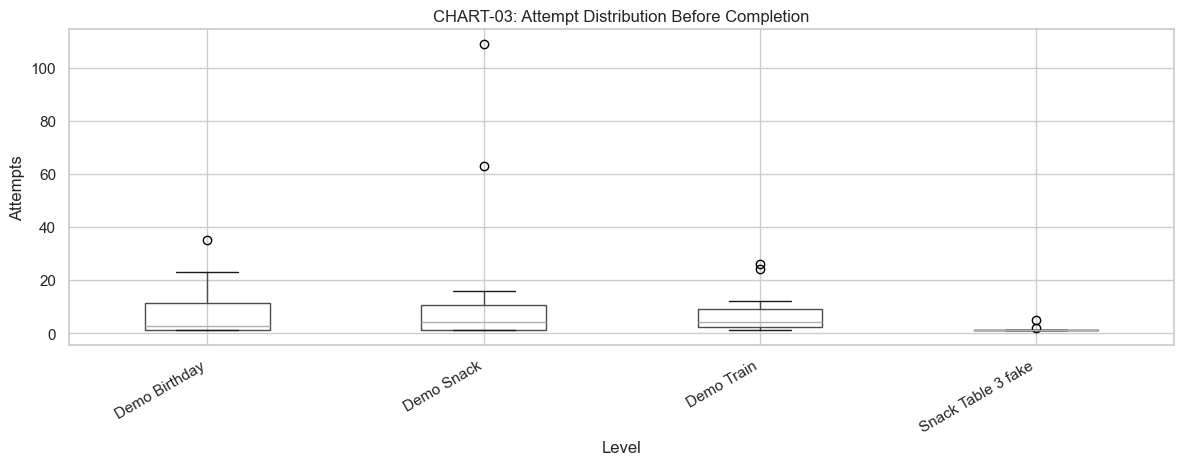

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
df_03.boxplot(column='attempt_count', by='level_name', ax=ax)
ax.set_title('CHART-03: Attempt Distribution Before Completion')
ax.set_xlabel('Level')
ax.set_ylabel('Attempts')
plt.suptitle('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### CHART-04 — Level Pass Rate by Child B Personality
**Q:** Which Child B personality has the lowest completion rate?

In [18]:
df_04 = query("""
SELECT
    lf.personality_childb                                          AS personality_child_b,
    lf.levelname                                                   AS level_name,
    COUNT(*)                                                       AS total_sessions,
    SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)       AS completed_sessions,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS pass_rate_pct
FROM levelflows lf
WHERE lf.personality_childb IS NOT NULL
GROUP BY lf.personality_childb, lf.levelname
ORDER BY pass_rate_pct ASC
""")

df_04

,personality_child_b,level_name,total_sessions,completed_sessions,pass_rate_pct
0,War_Refugee,Snack Table 3 fake,7,0,0E-15
1,PDA_Autism,Snack Table 3 fake,2,0,0E-15
2,Foster_Care,Snack Table 3 fake,3,0,0E-15
3,Bad_Day,Snack Table 3 fake,1,0,0E-15
4,Indigenous Off-Reserve,Demo Train,21,2,9.500000000000000
5,Indigenous Family,Demo Birthday,21,2,9.500000000000000
6,PDA_Autism,Demo Birthday,12,2,16.700000000000000
7,Bad_Day,Demo Birthday,40,7,17.500000000000000
8,Foster_Care,Demo Birthday,10,2,20.000000000000000
9,War_Refugee,Demo Train,10,2,20.000000000000000


### CHART-05 — Personality Combination Difficulty Matrix (Heatmap)
**Q:** Which Child A + Child B personality combo is hardest?

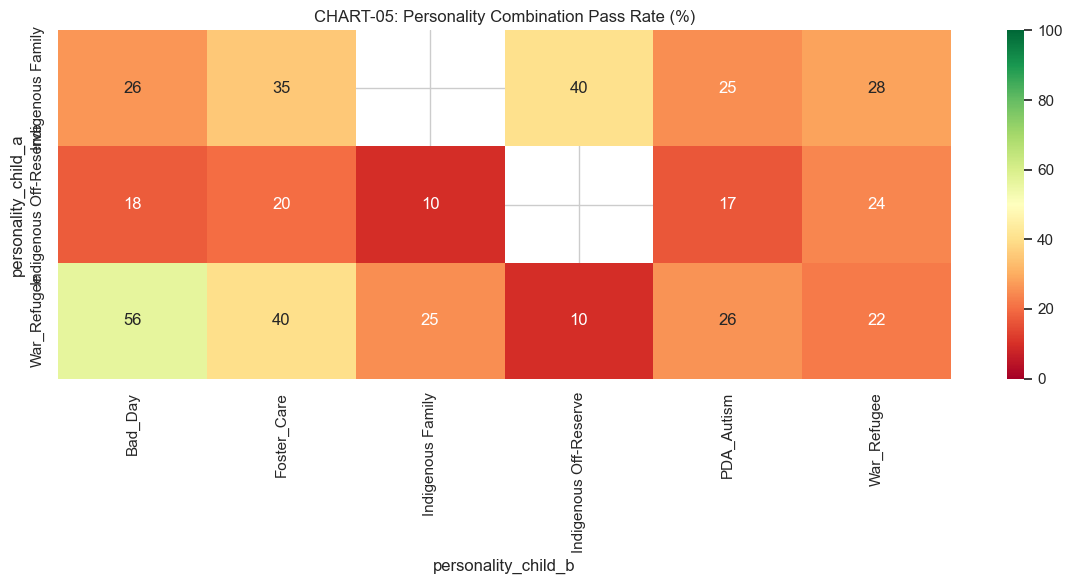

In [20]:
df_05 = query("""
SELECT
    COALESCE(lf.personality_childa, 'Unknown')                     AS personality_child_a,
    COALESCE(lf.personality_childb, 'Unknown')                     AS personality_child_b,
    COUNT(*)                                                       AS total_sessions,
    SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)       AS completions,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS pass_rate_pct
FROM levelflows lf
GROUP BY lf.personality_childa, lf.personality_childb
ORDER BY pass_rate_pct ASC
""")

# ✅ ensure numeric
df_05["pass_rate_pct"] = pd.to_numeric(df_05["pass_rate_pct"], errors="coerce")

pivot_05 = df_05.pivot_table(
    index="personality_child_a",
    columns="personality_child_b",
    values="pass_rate_pct",
    aggfunc="mean",
)

# ✅ ensure the pivot is numeric (and NaN allowed)
pivot_05 = pivot_05.apply(pd.to_numeric, errors="coerce").astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot_05,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0, vmax=100,
    ax=ax
)
ax.set_title("CHART-05: Personality Combination Pass Rate (%)")
plt.tight_layout()
plt.show()

### CHART-06 — Scene Completion Rate by Personality (Heatmap)
**Q:** For each personality, which scene do students fail the most?

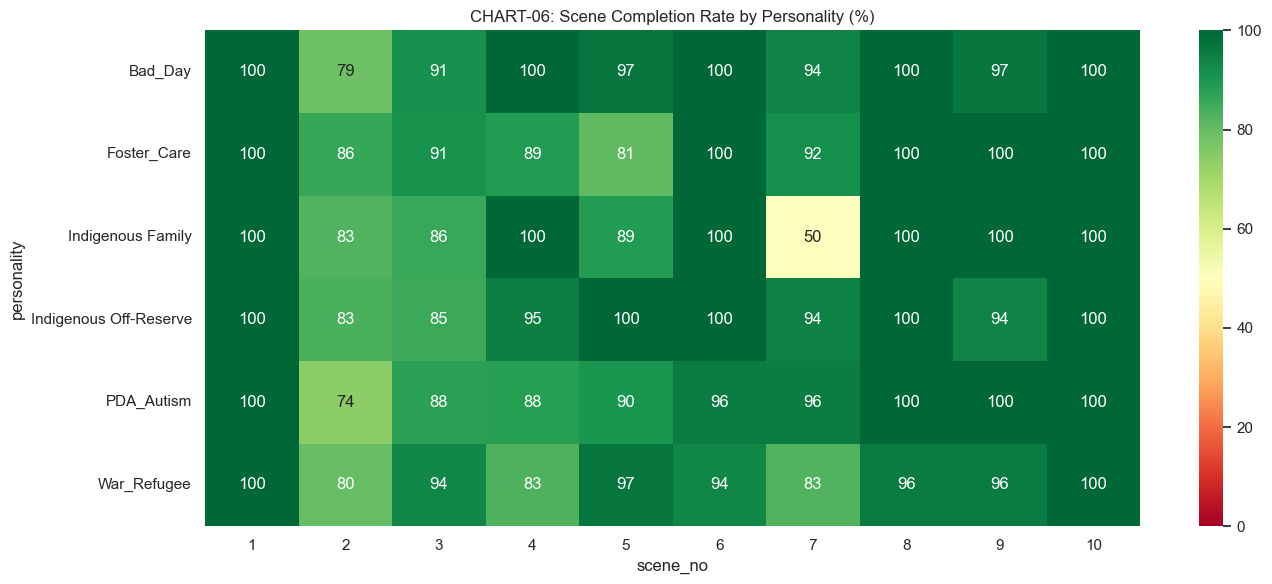

In [22]:
df_06 = query("""
SELECT
    lf.personality_childb                                          AS personality,
    CAST(json_extract_scalar(scene_obj, '$.sceneNo') AS BIGINT)    AS scene_no,
    COUNT(*)                                                       AS attempts,
    SUM(CASE WHEN json_extract_scalar(scene_obj, '$.sceneComplete') = 'true' THEN 1 ELSE 0 END) AS completions,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN json_extract_scalar(scene_obj, '$.sceneComplete') = 'true' THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS completion_pct
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
WHERE lf.personality_childb IS NOT NULL
GROUP BY lf.personality_childb, json_extract_scalar(scene_obj, '$.sceneNo')
ORDER BY personality, scene_no
""")

# ✅ force numeric
df_06["completion_pct"] = pd.to_numeric(df_06["completion_pct"], errors="coerce")

pivot_06 = df_06.pivot_table(
    index="personality",
    columns="scene_no",
    values="completion_pct",
    aggfunc="mean"
)

# ✅ ensure float matrix
pivot_06 = pivot_06.apply(pd.to_numeric, errors="coerce").astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_06,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    ax=ax
)

ax.set_title("CHART-06: Scene Completion Rate by Personality (%)")
plt.tight_layout()
plt.show()

### CHART-07 — Correct vs Incorrect Responses Per Scene
**Q:** In which scenes do students give the most incorrect responses?

In [23]:
df_07 = query("""
SELECT
    lf.levelname                                                   AS level_name,
    lf.personality_childb                                          AS personality,
    CAST(json_extract_scalar(scene_obj, '$.sceneNo') AS BIGINT)    AS scene_no,
    COUNT(*)                                                       AS total_responses,
    SUM(CASE WHEN json_extract_scalar(conv_obj, '$.isCorrect') = 'true' THEN 1 ELSE 0 END)  AS correct_responses,
    SUM(CASE WHEN json_extract_scalar(conv_obj, '$.isCorrect') = 'false' THEN 1 ELSE 0 END) AS incorrect_responses,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN json_extract_scalar(conv_obj, '$.isCorrect') = 'true' THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS accuracy_pct
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
CROSS JOIN UNNEST(CAST(json_extract(scene_obj, '$.conversations') AS ARRAY(JSON))) AS t2(conv_obj)
WHERE json_extract_scalar(conv_obj, '$.type') = 'user'
GROUP BY lf.levelname, lf.personality_childb, json_extract_scalar(scene_obj, '$.sceneNo')
ORDER BY level_name, scene_no
""")

df_07

,level_name,personality,scene_no,total_responses,correct_responses,incorrect_responses,accuracy_pct
0,Demo Birthday,Bad_Day,2,43,23,20,53.500000000000000
1,Demo Birthday,PDA_Autism,2,9,5,4,55.600000000000000
2,Demo Birthday,Indigenous Family,2,25,10,15,40.000000000000000
3,Demo Birthday,War_Refugee,2,32,13,19,40.600000000000000
4,Demo Birthday,Foster_Care,2,14,8,6,57.100000000000000
...,...,...,...,...,...,...,...
147,Snack Table 3 fake,Foster_Care,2,2,0,2,0E-15
148,Snack Table 3 fake,War_Refugee,3,24,1,23,4.200000000000000
149,Snack Table 3 fake,PDA_Autism,3,7,1,6,14.300000000000000
150,Snack Table 3 fake,PDA_Autism,4,8,0,8,0E-15


### CHART-08 — Blame Language Usage by Personality & Scene
**Q:** In which personality + scene do students use blame language most?

TypeError: Image data of dtype object cannot be converted to float

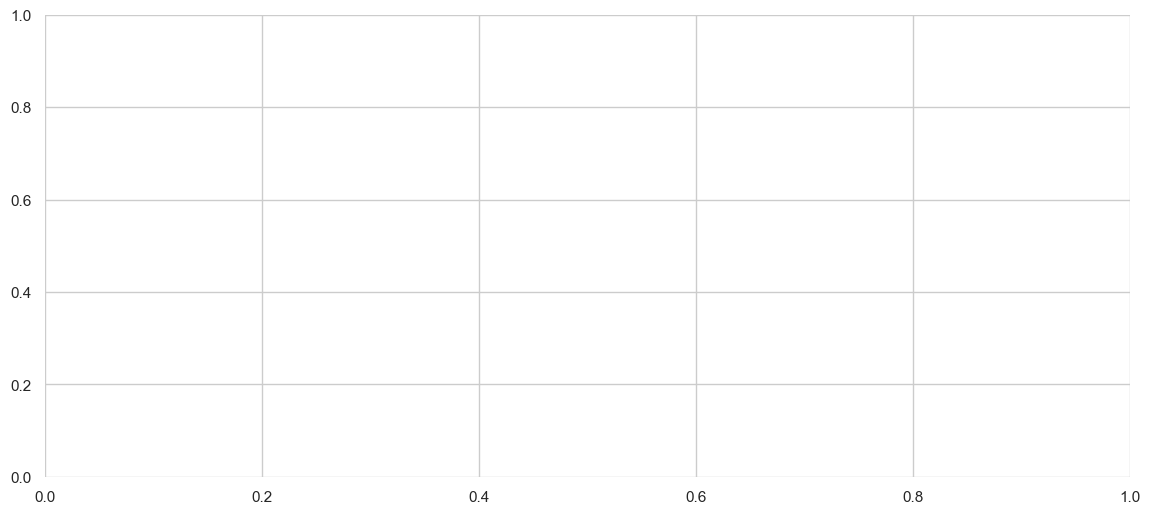

In [24]:
df_08 = query("""
SELECT
    lf.personality_childb                                          AS personality,
    CAST(json_extract_scalar(scene_obj, '$.sceneNo') AS BIGINT)    AS scene_no,
    COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END)   AS total_user_responses,
    COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user'
               AND json_extract_scalar(conv_obj, '$.blame') = 'true' THEN 1 END)   AS blame_responses,
    COALESCE(ROUND(
        100.0 * COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user'
                           AND json_extract_scalar(conv_obj, '$.blame') = 'true' THEN 1 END)
        / NULLIF(COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END), 0), 1
    ), 0)                                                          AS blame_rate_pct
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
CROSS JOIN UNNEST(CAST(json_extract(scene_obj, '$.conversations') AS ARRAY(JSON))) AS t2(conv_obj)
WHERE lf.personality_childb IS NOT NULL
GROUP BY lf.personality_childb, json_extract_scalar(scene_obj, '$.sceneNo')
ORDER BY personality, scene_no
""")

pivot_08 = df_08.pivot_table(index='personality', columns='scene_no', values='blame_rate_pct')
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_08, annot=True, fmt='.0f', cmap='RdYlGn_r', vmin=0, vmax=100, ax=ax)
ax.set_title('CHART-08: Blame Rate (%) by Personality & Scene')
plt.tight_layout()
plt.show()

### CHART-09 — Average Responses Per Scene
**Q:** How many attempts does a student need per scene on average?

In [ ]:
df_09 = query("""
SELECT
    lf.levelname                                                   AS level_name,
    lf.personality_childb                                          AS personality,
    CAST(json_extract_scalar(scene_obj, '$.sceneNo') AS BIGINT)    AS scene_no,
    COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END)  AS total_user_responses,
    COUNT(DISTINCT lf._id)                                         AS unique_sessions,
    COALESCE(ROUND(
        1.0 * COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END)
        / NULLIF(COUNT(DISTINCT lf._id), 0), 2
    ), 0)                                                          AS avg_responses_per_session
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
CROSS JOIN UNNEST(CAST(json_extract(scene_obj, '$.conversations') AS ARRAY(JSON))) AS t2(conv_obj)
GROUP BY lf.levelname, lf.personality_childb, json_extract_scalar(scene_obj, '$.sceneNo')
ORDER BY level_name, scene_no
""")

df_09

### CHART-12 — NLP Model Accuracy by Level Over Time
**Q:** Are NLP models improving over time for each level?

In [25]:
df_12 = query("""
SELECT
    json_extract_scalar(tm.level, '$.name')  AS level_name,
    tm.modellink                             AS model_link,
    tm.accuracy                              AS accuracy_score,
    tm.blame                                 AS is_blame_model,
    CAST(tm.lastmodelupdate AS DATE)         AS update_date,
    CARDINALITY(tm.originalsentences)        AS original_sentence_count,
    CARDINALITY(tm.generatedsentences)       AS generated_sentence_count
FROM trainingmodels tm
WHERE tm.accuracy IS NOT NULL
ORDER BY update_date ASC
""")

df_12

,level_name,model_link,accuracy_score,is_blame_model,update_date,original_sentence_count,generated_sentence_count
0,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Give_encourage...,0,False,2026-01-26,1,10
1,Snack Table 3,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Sportscasting_...,0,False,2026-01-26,1,9
2,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Ask_what_happe...,0,False,2026-01-26,1,10
3,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Acknowledge_Ch...,0,False,2026-01-26,1,10
4,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Acknowledge_Ch...,0,False,2026-01-26,1,10
5,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Ask_for_soluti...,0,False,2026-01-26,1,10
6,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Repeat_and_ack...,0,False,2026-01-26,1,10
7,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Repeat_and_ack...,0,False,2026-01-26,1,10
8,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Repeat_and_ack...,0,False,2026-01-26,1,10
9,Snack Table 3 fake,https://storage.googleapis.com/langara-nlp/Snack_Table_3_fake_Blame_696e709b...,35,True,2026-02-28,2,20


### CHART-13 — Blame Model vs General Model Accuracy
**Q:** Do blame-specific NLP models achieve higher or lower accuracy than general models?

In [26]:
df_13 = query("""
SELECT
    json_extract_scalar(tm.level, '$.name')             AS level_name,
    CASE WHEN tm.blame = true THEN 'Blame Model'
         ELSE 'General Model' END                       AS model_type,
    ROUND(AVG(tm.accuracy), 3)                          AS avg_accuracy,
    MAX(tm.accuracy)                                    AS max_accuracy,
    COUNT(*)                                            AS model_count
FROM trainingmodels tm
WHERE tm.accuracy IS NOT NULL
GROUP BY json_extract_scalar(tm.level, '$.name'), tm.blame
ORDER BY level_name, model_type
""")

df_13

,level_name,model_type,avg_accuracy,max_accuracy,model_count
0,Demo Birthday,Blame Model,85.000,85,1
1,Demo Birthday,General Model,85.778,99,9
2,Demo Snack,Blame Model,96.000,96,1
3,Demo Snack,General Model,85.000,94,9
4,Demo Train,Blame Model,67.000,67,1
5,Demo Train,General Model,89.111,96,9
6,Snack Table 3,General Model,0.000,0,1
7,Snack Table 3 fake,Blame Model,35.000,35,1
8,Snack Table 3 fake,General Model,0.000,0,8


### CHART-14 — Student Activity Over Time
**Q:** When are students most actively using the VR app?

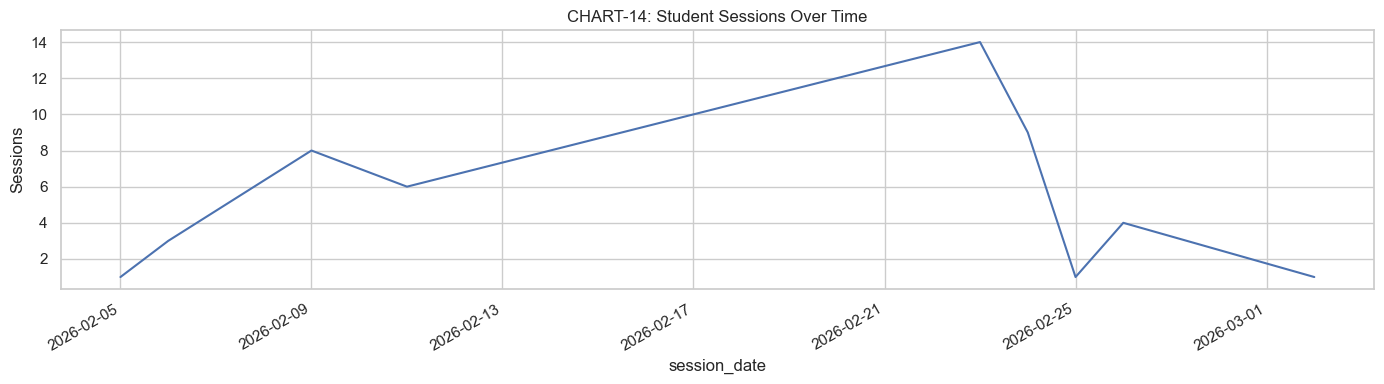

In [27]:
df_14 = query("""
SELECT
    CAST(lf."create" AS DATE)    AS session_date,
    COUNT(*)                     AS sessions_started,
    COUNT(DISTINCT lf.userid)    AS unique_students,
    lf.levelname                 AS level_name
FROM levelflows lf
JOIN users u ON u._id = lf.userid
WHERE u.role = 'student'
GROUP BY CAST(lf."create" AS DATE), lf.levelname
ORDER BY session_date
""")

df_14['session_date'] = pd.to_datetime(df_14['session_date'])
daily = df_14.groupby('session_date')['sessions_started'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax, title='CHART-14: Student Sessions Over Time')
ax.set_ylabel('Sessions')
plt.tight_layout()
plt.show()

### CHART-17 — Pass Rate by Personality & Child B Avatar
**Q:** Does the Child B avatar body affect session pass rate within each personality type?

In [28]:
df_17 = query("""
SELECT
    lf.personality_childb                               AS personality,
    json_extract_scalar(lf.avatarinfo, '$.ChildB')      AS childb_avatar,
    COUNT(*)                                            AS sessions_attempted,
    SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END) AS sessions_completed,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                               AS pass_rate_pct
FROM levelflows lf
WHERE lf.personality_childb IS NOT NULL
  AND lf.avatarinfo IS NOT NULL
GROUP BY lf.personality_childb, json_extract_scalar(lf.avatarinfo, '$.ChildB')
ORDER BY personality, childb_avatar
""")

df_17

,personality,childb_avatar,sessions_attempted,sessions_completed,pass_rate_pct
0,Bad_Day,AMAN,3,2,66.700000000000000
1,Bad_Day,JAMES,26,7,26.900000000000000
2,Bad_Day,MAX,56,13,23.200000000000000
3,Bad_Day,MIN,1,0,0E-15
4,Bad_Day,RIVER,8,4,50.000000000000000
5,Foster_Care,AMAN,9,2,22.200000000000000
6,Foster_Care,CASSIE,1,0,0E-15
7,Foster_Care,JAMES,3,0,0E-15
8,Foster_Care,MIN,22,13,59.100000000000000
9,Foster_Care,RIVER,41,11,26.800000000000000


---
## 3. New Research Queries

Exploratory queries not in the original guide — designed to surface deeper research insights.

### NEW-01 — Student Learning Curve: Do Repeated Attempts Improve Outcomes?
**Q:** Do students who retry a level complete it at higher rates on later attempts?  
Ranks each attempt per student per level chronologically and measures whether completion probability increases with attempt number.

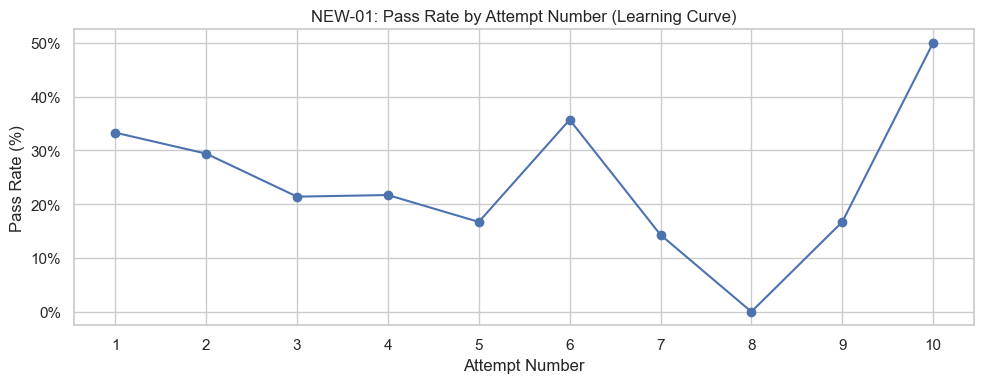

,attempt_number,total_sessions,completed,pass_rate_pct
0,1,51,17,33.300000000000000
1,2,34,10,29.400000000000000
2,3,28,6,21.400000000000000
3,4,23,5,21.700000000000000
4,5,18,3,16.700000000000000
5,6,14,5,35.700000000000000
6,7,14,2,14.300000000000000
7,8,12,0,0E-15
8,9,12,2,16.700000000000000
9,10,12,6,50.000000000000000


In [29]:
df_new01 = query("""
SELECT
    attempt_number,
    COUNT(*)                                                       AS total_sessions,
    SUM(CASE WHEN levelcomplete = true THEN 1 ELSE 0 END)          AS completed,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS pass_rate_pct
FROM (
    SELECT
        lf.userid,
        lf.levelname,
        lf.levelcomplete,
        ROW_NUMBER() OVER (
            PARTITION BY lf.userid, lf.levelname
            ORDER BY lf."create"
        )                                                          AS attempt_number
    FROM levelflows lf
) ranked
WHERE attempt_number <= 10
GROUP BY attempt_number
ORDER BY attempt_number
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_new01['attempt_number'], df_new01['pass_rate_pct'], marker='o')
ax.set_title('NEW-01: Pass Rate by Attempt Number (Learning Curve)')
ax.set_xlabel('Attempt Number')
ax.set_ylabel('Pass Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(df_new01['attempt_number'])
plt.tight_layout()
plt.show()

df_new01

### NEW-02 — First-Try Success Rate by Level
**Q:** What fraction of students pass each level on their very first attempt?  
High first-try pass rate = level is well-designed or too easy. Low = students need multiple attempts to understand.

In [30]:
df_new02 = query("""
SELECT
    levelname                                                      AS level_name,
    COUNT(*)                                                       AS first_attempt_students,
    SUM(CASE WHEN levelcomplete = true THEN 1 ELSE 0 END)          AS passed_first_try,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS first_try_pass_rate_pct
FROM (
    SELECT
        userid, levelname, levelcomplete,
        ROW_NUMBER() OVER (PARTITION BY userid, levelname ORDER BY "create") AS rn
    FROM levelflows
) t
WHERE rn = 1
GROUP BY levelname
ORDER BY first_try_pass_rate_pct ASC
""")

ax = df_new02.set_index('level_name')['first_try_pass_rate_pct'].sort_values().plot(
    kind='barh', figsize=(10, 5), title='NEW-02: First-Try Pass Rate by Level'
)
ax.set_xlabel('Pass Rate (%)')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

df_new02

TypeError: no numeric data to plot

### NEW-03 — Student Retention: Return Rate After First Session
**Q:** How many students return to play more than once?  
Identifies whether students are self-motivated to retry or only play when assigned.

In [31]:
df_new03 = query("""
SELECT
    session_count_bucket,
    COUNT(DISTINCT userid)                                        AS students
FROM (
    SELECT
        userid,
        CASE
            WHEN COUNT(*) = 1 THEN '1 session (never returned)'
            WHEN COUNT(*) BETWEEN 2 AND 5 THEN '2-5 sessions'
            WHEN COUNT(*) BETWEEN 6 AND 10 THEN '6-10 sessions'
            ELSE '11+ sessions'
        END AS session_count_bucket
    FROM levelflows lf
    JOIN users u ON u._id = lf.userid
    WHERE u.role = 'student'
    GROUP BY userid
) t
GROUP BY session_count_bucket
ORDER BY MIN(CASE session_count_bucket
    WHEN '1 session (never returned)' THEN 1
    WHEN '2-5 sessions' THEN 2
    WHEN '6-10 sessions' THEN 3
    ELSE 4 END)
""")

df_new03.set_index('session_count_bucket')['students'].plot(
    kind='pie', autopct='%1.1f%%', figsize=(7, 7),
    title='NEW-03: Student Retention (Session Count Distribution)'
)
plt.ylabel('')
plt.tight_layout()
plt.show()

df_new03

TrinoUserError: TrinoUserError(type=USER_ERROR, name=COLUMN_NOT_FOUND, message="line 20:19: Invalid reference to output projection attribute from ORDER BY aggregation", query_id=20260303_185854_00281_sqwjj)

### NEW-04 — Personality-Level Difficulty Index (Composite Score)
**Q:** Which personality × level combination is objectively hardest?  
Combines low pass rate, high blame rate, and high avg attempts into a single difficulty index.

In [32]:
df_new04 = query("""
SELECT
    lf.levelname                                                   AS level_name,
    lf.personality_childb                                          AS personality,
    COUNT(DISTINCT lf.userid)                                      AS unique_students,
    COUNT(*)                                                       AS total_sessions,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0), 1
    ), 0)                                                          AS pass_rate_pct,
    COALESCE(ROUND(
        1.0 * COUNT(*)
        / NULLIF(COUNT(DISTINCT lf.userid), 0), 2
    ), 0)                                                          AS avg_attempts_per_student,
    -- Difficulty index: lower pass rate + more attempts = harder
    COALESCE(ROUND(
        (100.0 - (100.0 * SUM(CASE WHEN lf.levelcomplete = true THEN 1 ELSE 0 END)
        / NULLIF(COUNT(*), 0)))
        * (1.0 * COUNT(*) / NULLIF(COUNT(DISTINCT lf.userid), 0)) / 10.0
    , 2), 0)                                                       AS difficulty_index
FROM levelflows lf
WHERE lf.personality_childb IS NOT NULL
GROUP BY lf.levelname, lf.personality_childb
HAVING COUNT(DISTINCT lf.userid) >= 3
ORDER BY difficulty_index DESC
""")

df_new04.head(15)

,level_name,personality,unique_students,total_sessions,pass_rate_pct,avg_attempts_per_student,difficulty_index
0,Demo Snack,Foster_Care,4,47,38.300000000000000,11.75000000000000000,72.500000
1,Demo Snack,War_Refugee,8,59,32.200000000000000,7.38000000000000000,50.000000
2,Demo Birthday,Indigenous Family,4,21,9.500000000000000,5.25000000000000000,47.500000
3,Demo Snack,PDA_Autism,10,57,24.600000000000000,5.70000000000000000,43.000000
4,Demo Birthday,Bad_Day,8,40,17.500000000000000,5.00000000000000000,41.250000
5,Demo Birthday,War_Refugee,6,29,24.100000000000000,4.83000000000000000,36.670000
6,Demo Train,PDA_Autism,6,28,28.600000000000000,4.67000000000000000,33.330000
7,Demo Snack,Bad_Day,9,35,22.900000000000000,3.89000000000000000,30.000000
8,Demo Train,Indigenous Off-Reserve,7,21,9.500000000000000,3.00000000000000000,27.140000
9,Demo Snack,Indigenous Off-Reserve,9,37,40.500000000000000,4.11000000000000000,24.440000


### NEW-05 — Session Time-of-Day Analysis
**Q:** When during the day do students play? Peaks may reveal class schedule or voluntary study patterns.

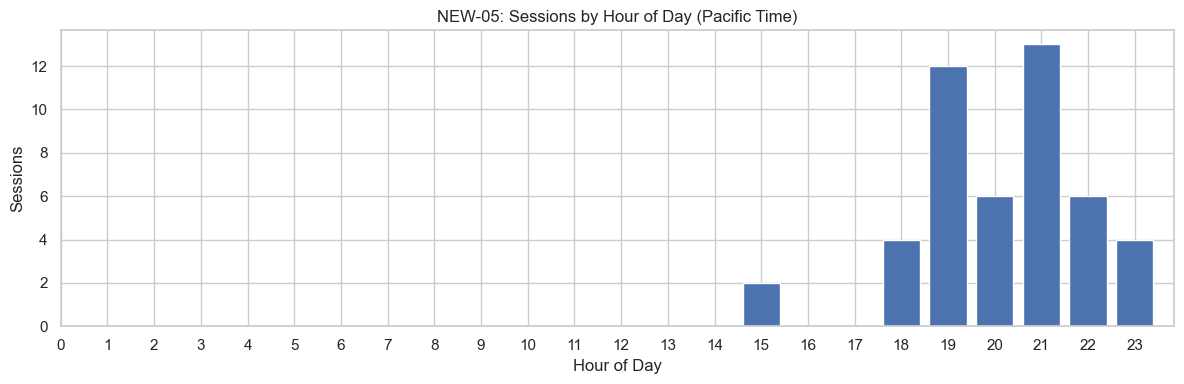

,hour_of_day,sessions,unique_students
0,15,2,2
1,18,4,1
2,19,12,3
3,20,6,3
4,21,13,4
5,22,6,2
6,23,4,2


In [33]:
df_new05 = query("""
SELECT
    HOUR(lf."create")                AS hour_of_day,
    COUNT(*)                         AS sessions,
    COUNT(DISTINCT lf.userid)        AS unique_students
FROM levelflows lf
JOIN users u ON u._id = lf.userid
WHERE u.role = 'student'
GROUP BY HOUR(lf."create")
ORDER BY hour_of_day
""")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_new05['hour_of_day'], df_new05['sessions'])
ax.set_title('NEW-05: Sessions by Hour of Day (Pacific Time)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Sessions')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

df_new05

### NEW-06 — Day-of-Week Activity Pattern
**Q:** Are students more active on certain days? Weekday vs weekend usage reveals assignment-driven vs self-directed learning.

In [ ]:
df_new06 = query("""
SELECT
    DAY_OF_WEEK(CAST(lf."create" AS DATE))  AS day_of_week_num,
    DATE_FORMAT(lf."create", '%W')           AS day_name,
    COUNT(*)                                 AS sessions,
    COUNT(DISTINCT lf.userid)                AS unique_students
FROM levelflows lf
JOIN users u ON u._id = lf.userid
WHERE u.role = 'student'
GROUP BY DAY_OF_WEEK(CAST(lf."create" AS DATE)), DATE_FORMAT(lf."create", '%W')
ORDER BY day_of_week_num
""")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_new06['day_name'], df_new06['sessions'])
ax.set_title('NEW-06: Sessions by Day of Week')
ax.set_ylabel('Sessions')
plt.tight_layout()
plt.show()

df_new06

### NEW-07 — Level Play Order (Which Levels Do Students Play First?)
**Q:** What is the most common order students play levels in?  
Shows whether students follow a prescribed curriculum path or play freely.

In [34]:
df_new07 = query("""
SELECT
    level_order,
    levelname,
    COUNT(DISTINCT userid)   AS students_who_played_this_nth
FROM (
    SELECT
        userid,
        levelname,
        DENSE_RANK() OVER (PARTITION BY userid ORDER BY MIN("create")) AS level_order
    FROM levelflows
    GROUP BY userid, levelname
) t
WHERE level_order <= 5
GROUP BY level_order, levelname
ORDER BY level_order, students_who_played_this_nth DESC
""")

df_new07

,level_order,levelname,students_who_played_this_nth
0,1,Demo Train,8
1,1,Demo Snack,6
2,1,Demo Birthday,2
3,2,Demo Birthday,5
4,2,Demo Train,4
5,2,Snack Table 3 fake,3
6,2,Demo Snack,2
7,3,Demo Snack,6
8,3,Demo Birthday,3
9,3,Snack Table 3 fake,2


### NEW-08 — NLP Training Data Growth Over Time
**Q:** How are training sentence counts growing as more student data is collected?  
More data should correlate with better model accuracy.

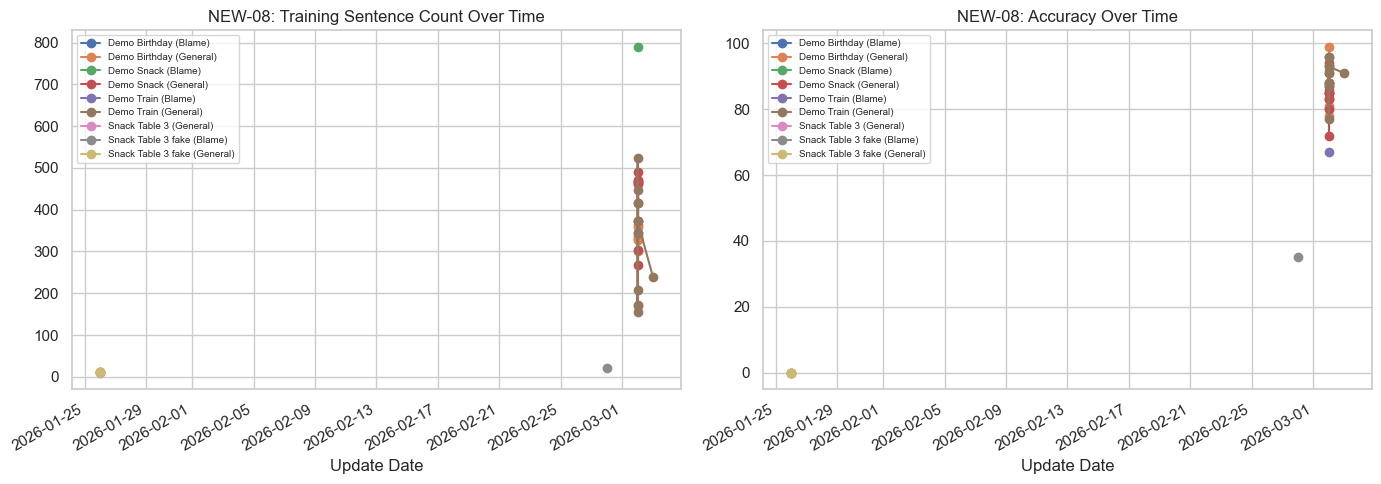

,level_name,update_date,model_type,original_sentences,generated_sentences,total_training_sentences,accuracy_score
0,Snack Table 3 fake,2026-01-26,General,1,10,11,0
1,Snack Table 3,2026-01-26,General,1,9,10,0
2,Snack Table 3 fake,2026-01-26,General,1,10,11,0
3,Snack Table 3 fake,2026-01-26,General,1,10,11,0
4,Snack Table 3 fake,2026-01-26,General,1,10,11,0
5,Snack Table 3 fake,2026-01-26,General,1,10,11,0
6,Snack Table 3 fake,2026-01-26,General,1,10,11,0
7,Snack Table 3 fake,2026-01-26,General,1,10,11,0
8,Snack Table 3 fake,2026-01-26,General,1,10,11,0
9,Snack Table 3 fake,2026-02-28,Blame,2,20,22,35


In [35]:
df_new08 = query("""
SELECT
    json_extract_scalar(tm.level, '$.name')  AS level_name,
    CAST(tm.lastmodelupdate AS DATE)         AS update_date,
    CASE WHEN tm.blame = true THEN 'Blame' ELSE 'General' END AS model_type,
    CARDINALITY(tm.originalsentences)        AS original_sentences,
    CARDINALITY(tm.generatedsentences)       AS generated_sentences,
    CARDINALITY(tm.originalsentences)
    + CARDINALITY(tm.generatedsentences)     AS total_training_sentences,
    tm.accuracy                              AS accuracy_score
FROM trainingmodels tm
WHERE tm.accuracy IS NOT NULL
ORDER BY update_date ASC
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['total_training_sentences', 'accuracy_score'],
    ['Training Sentence Count Over Time', 'Accuracy Over Time']
):
    for (level, mtype), grp in df_new08.groupby(['level_name', 'model_type']):
        ax.plot(grp['update_date'], grp[col], marker='o', label=f'{level} ({mtype})')
    ax.set_title(f'NEW-08: {title}')
    ax.set_xlabel('Update Date')
    ax.legend(fontsize=7)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

df_new08

### NEW-09 — Scenes Where Blame Predicts Failure
**Q:** Is blame language a leading indicator of session failure?  
Joins session-level outcomes with per-scene blame rates to see if blaming correlates with not completing the level.

In [ ]:
df_new09 = query("""
SELECT
    lf.levelname                                                   AS level_name,
    lf.levelcomplete,
    COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END)         AS total_responses,
    COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user'
               AND json_extract_scalar(conv_obj, '$.blame') = 'true' THEN 1 END)        AS blame_responses,
    COALESCE(ROUND(
        100.0 * COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user'
                           AND json_extract_scalar(conv_obj, '$.blame') = 'true' THEN 1 END)
        / NULLIF(COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END), 0), 1
    ), 0)                                                          AS blame_rate_pct
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
CROSS JOIN UNNEST(CAST(json_extract(scene_obj, '$.conversations') AS ARRAY(JSON))) AS t2(conv_obj)
GROUP BY lf.levelname, lf.levelcomplete
ORDER BY level_name, lf.levelcomplete
""")

# Pivot: compare blame rate for completed vs not completed sessions
pivot_09 = df_new09.pivot_table(index='level_name', columns='levelcomplete', values='blame_rate_pct')
pivot_09.columns = ['Failed', 'Passed']
pivot_09.plot(kind='bar', figsize=(12, 5),
              title='NEW-09: Blame Rate (%) — Passed vs Failed Sessions by Level',
              ylabel='Blame Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df_new09

### NEW-10 — Student Progress: Scenes Reached Per Level (Never Completed)
**Q:** For students who never completed a level, how far did they get?  
Reveals the 'cliff' scene where students give up entirely.

In [ ]:
df_new10 = query("""
SELECT
    lf.levelname                                                   AS level_name,
    MAX(CAST(json_extract_scalar(scene_obj, '$.sceneNo') AS BIGINT)) AS furthest_scene_reached,
    COUNT(DISTINCT lf.userid)                                      AS students
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
WHERE lf.userid NOT IN (
    SELECT DISTINCT userid FROM levelflows WHERE levelcomplete = true
)
GROUP BY lf.levelname, lf.userid
-- Aggregate across students for distribution
""")

# Show distribution of furthest scene per level for students who never completed
for level, grp in df_new10.groupby('level_name'):
    print(f"\n{level}:")
    print(grp['furthest_scene_reached'].value_counts().sort_index().to_string())

### NEW-11 — Response Accuracy Improvement Within a Session
**Q:** Within a single session, do students get more accurate as they progress through scenes?  
Tests whether learning happens within a single play session.

In [ ]:
df_new11 = query("""
SELECT
    CAST(json_extract_scalar(scene_obj, '$.sceneNo') AS BIGINT)    AS scene_no,
    COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END)        AS responses,
    SUM(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user'
             AND json_extract_scalar(conv_obj, '$.isCorrect') = 'true' THEN 1 ELSE 0 END) AS correct,
    COALESCE(ROUND(
        100.0 * SUM(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user'
                         AND json_extract_scalar(conv_obj, '$.isCorrect') = 'true' THEN 1 ELSE 0 END)
        / NULLIF(COUNT(CASE WHEN json_extract_scalar(conv_obj, '$.type') = 'user' THEN 1 END), 0), 1
    ), 0)                                                          AS accuracy_pct
FROM levelflows lf
CROSS JOIN UNNEST(CAST(lf.scene AS ARRAY(JSON))) AS t(scene_obj)
CROSS JOIN UNNEST(CAST(json_extract(scene_obj, '$.conversations') AS ARRAY(JSON))) AS t2(conv_obj)
GROUP BY json_extract_scalar(scene_obj, '$.sceneNo')
ORDER BY scene_no
""")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_new11['scene_no'], df_new11['accuracy_pct'], marker='o', color='steelblue')
ax.set_title('NEW-11: Response Accuracy by Scene Number (Across All Levels)')
ax.set_xlabel('Scene Number')
ax.set_ylabel('Accuracy (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

df_new11

### NEW-12 — Student Cohort Comparison by Month of First Session
**Q:** Do students who started in earlier cohorts (semesters) perform better?  
Useful for measuring whether app improvements or instructor guidance improve outcomes over time.

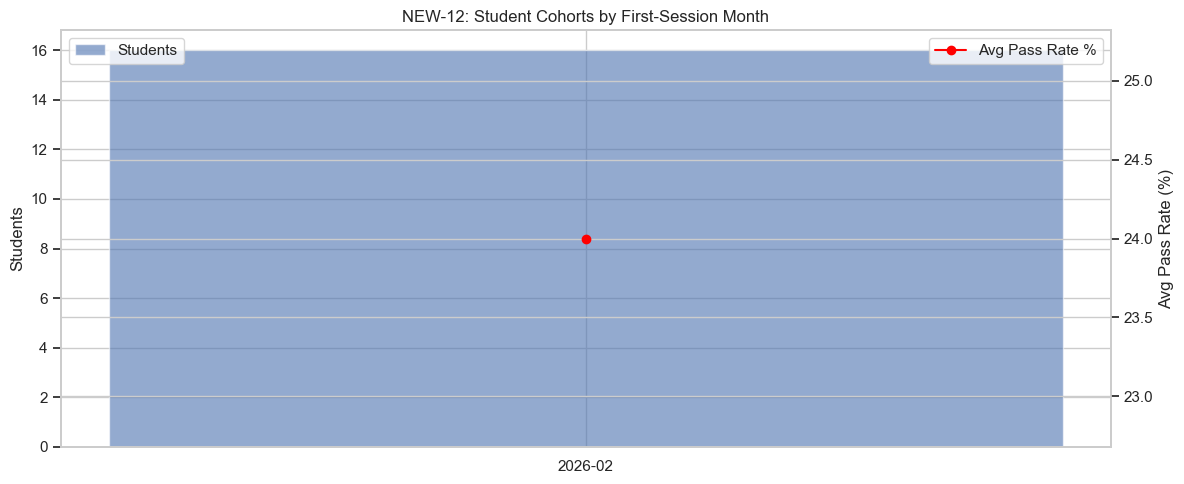

,cohort_month,students,total_sessions,avg_sessions_per_student,avg_pass_rate_pct
0,2026-02,16,465,29.1,24.000000000000000


In [36]:
df_new12 = query("""
SELECT
    cohort_month,
    COUNT(DISTINCT userid)                                        AS students,
    SUM(total_sessions)                                           AS total_sessions,
    ROUND(AVG(total_sessions), 1)                                 AS avg_sessions_per_student,
    ROUND(AVG(pass_rate), 1)                                      AS avg_pass_rate_pct
FROM (
    SELECT
        userid,
        DATE_FORMAT(MIN("create"), '%Y-%m')   AS cohort_month,
        COUNT(*)                              AS total_sessions,
        COALESCE(ROUND(
            100.0 * SUM(CASE WHEN levelcomplete = true THEN 1 ELSE 0 END)
            / NULLIF(COUNT(*), 0), 1
        ), 0)                                 AS pass_rate
    FROM levelflows
    GROUP BY userid
) t
GROUP BY cohort_month
ORDER BY cohort_month
""")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(df_new12['cohort_month'], df_new12['students'], alpha=0.6, label='Students')
ax2.plot(df_new12['cohort_month'], df_new12['avg_pass_rate_pct'], color='red', marker='o', label='Avg Pass Rate %')
ax1.set_title('NEW-12: Student Cohorts by First-Session Month')
ax1.set_ylabel('Students')
ax2.set_ylabel('Avg Pass Rate (%)')
plt.xticks(rotation=30, ha='right')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

df_new12

1. Blame as a stress response
When a student can't resolve a scene, do they start blaming the child? The sequence matters — does blame language increase as scenes progress within a session? If yes, that's emotional fatigue showing up in language. This is a real psychological pattern — people under prolonged stress externalize responsibility.
Within a single session: scene_no → blame_rate ordered chronologically
Does blame_rate in scene 3 predict whether the student completes the level?

2. Does the student actually learn within a session vs across sessions?
Story 3 but sharper — not just "do they pass more on attempt 3" but how does their response pattern change. On attempt 1 they might give many incorrect responses before finding the right one. On attempt 3 they go straight to correct. That's the learning signal — response efficiency, not just pass/fail.
attempt_number (ROW_NUMBER by userid+levelname+create)
vs avg_responses_before_correct (how many wrong before right)

3. Personality empathy fingerprint
Each Child B personality represents a real marginalized group — PDA/Autism, War Refugee, Foster Care, Indigenous. The question is: which groups do ECE students find hardest to empathize with? Blame rate + incorrect rate + completion rate combined into one profile per personality tells you where empathy gaps are largest. That's publishable.
Per personality: blame_rate + incorrect_rate + completion_rate + avg_attempts
→ radar/spider chart or grouped bar showing the full difficulty profile

4. Time pressure and decision quality
scene_create gaps between scenes — students who rush through scenes (short gaps) vs students who pause. Do the rushers blame more? Do they complete less? This could reveal whether the app needs pacing interventions — forced reflection time between scenes.
time_gap between scenes (LEAD on scene_create by sceneNo)
vs sceneComplete + blame_rate for that scene

5. The recovery pattern
After a student fails a scene (sceneComplete = false), what happens next session? Do they attempt the same scene again more carefully (fewer responses, correct faster)? Or do they repeat the same mistakes? This shows whether failure in the app triggers reflection or just repetition.
session N: failed scene X → session N+1: same scene X
compare response pattern before vs after failure

6. Empathy under accumulation
Does blame/incorrect rate in early scenes predict level completion? If a student blames in scene 1, are they 3x more likely to fail by scene 4? That would mean early warning signals are detectable — instructors could intervene before the student fully disengages.
blame in scene 1 or 2 → levelcomplete
early_blame flag → completion outcome

7. Story 1: "Does struggling with a scene make you blame more?"
Connect scene completion + blame_rate at the scene level. If blame spikes exactly where completion drops, it means students under pressure default to blame language. This is a pedagogically critical finding — it tells instructors which scenes need more pre-teaching.
levelflows → scene[] → conversations[]
sceneComplete + blame_rate grouped by sceneNo + personality

8. Story 3: "The learning curve — do students actually improve across sessions?"
Use ROW_NUMBER() OVER (PARTITION BY userid, levelname ORDER BY create) to number each student's attempts at a level. Plot pass rate by attempt number. If attempt 1 pass rate is 20% but attempt 3 is 60%, the app is working. If it stays flat, students are not learning.

9. Story 6: "Conversation quality fingerprint by personality"
For each personality, what is the ratio of: correct responses / incorrect responses / blame responses across all scenes? Some personalities might trigger more blame, others more incorrect guesses. This gives a "difficulty profile" per personality that's richer than just pass rate.

10. Story 7: "Do students who take longer between scenes perform worse?"
scene_create timestamps inside scene[] — time between scene 1 and scene 2 vs completion. Long gaps might mean confusion or distraction. Short gaps might mean rushing without absorbing. Optimal pacing vs outcome.

In [ ]:
# Close connection when done
conn.close()
print('Connection closed.')